In [73]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset

In [71]:
data_dir = "/content/data"
batch_size = 32
epochs = 10
lr = 0.001
image_size = 224


transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

full_dataset = datasets.ImageFolder(data_dir, transform=transform)

In [66]:
class BinaryBrainDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.no_tumor_idx = dataset.class_to_idx['no']

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        label = 0 if label == self.no_tumor_idx else 1
        return img, label

binary_dataset = BinaryBrainDataset(full_dataset)

In [67]:
train_size = int(0.8 * len(binary_dataset))
val_size = len(binary_dataset) - train_size
train_dataset, val_dataset = random_split(binary_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [74]:

image_size = 224

class BrainTumorCNN(nn.Module):
    def __init__(self):
        super(BrainTumorCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )


        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            out = self.features(dummy)
            flattened_size = out.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



In [75]:

model = BrainTumorCNN()


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)


In [76]:

def evaluate(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return 100 * correct / total


for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_acc = evaluate(train_loader)
    val_acc = evaluate(val_loader)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {running_loss/len(train_loader):.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Acc: {val_acc:.2f}%")





Epoch [1/10] Loss: 0.8344 Train Acc: 80.94% Val Acc: 79.41%
Epoch [2/10] Loss: 0.5153 Train Acc: 80.94% Val Acc: 79.41%
Epoch [3/10] Loss: 0.4581 Train Acc: 81.19% Val Acc: 78.43%
Epoch [4/10] Loss: 0.4580 Train Acc: 81.19% Val Acc: 78.43%
Epoch [5/10] Loss: 0.4394 Train Acc: 80.94% Val Acc: 75.49%
Epoch [6/10] Loss: 0.3946 Train Acc: 81.19% Val Acc: 78.43%
Epoch [7/10] Loss: 0.3924 Train Acc: 81.68% Val Acc: 76.47%
Epoch [8/10] Loss: 0.3612 Train Acc: 82.18% Val Acc: 74.51%
Epoch [9/10] Loss: 0.3691 Train Acc: 82.43% Val Acc: 73.53%
Epoch [10/10] Loss: 0.3456 Train Acc: 82.43% Val Acc: 73.53%


Predicted: Tumor, Actual: Tumor


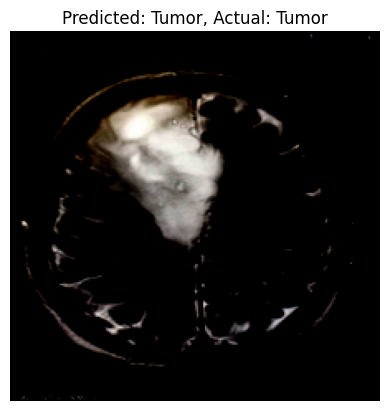

In [78]:
import random
import matplotlib.pyplot as plt
import torch


classes = ["No Tumor", "Tumor"]


idx = random.randint(0, len(val_dataset) - 1)
image, label = val_dataset[idx]


image_input = image.unsqueeze(0)

model.eval()
with torch.no_grad():
    outputs = model(image_input)
    _, predicted = torch.max(outputs, 1)


print(f"Predicted: {classes[predicted.item()]}, Actual: {classes[label]}")


plt.imshow(image.permute(1, 2, 0).cpu())
plt.title(f"Predicted: {classes[predicted.item()]}, Actual: {classes[label]}")
plt.axis('off')
plt.show()
